<a href="https://colab.research.google.com/github/Rashmika-Bandara/Predicting-Customer-Spending-from-Demographics-and-Purchase-Frequency/blob/sadani/EE7209_Customer_Spending_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# DATA MANIPULATION
import pandas as pd
import numpy as np

# VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

# MACHINE LEARNING
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
# GOOGLE DRIVE MOUNT (ONLY NEEDED IN COLAB)
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
except ModuleNotFoundError:
    print("Running outside Colab; skipping Google Drive mount.")


Running outside Colab; skipping Google Drive mount.


In [3]:
# LOAD DATA (LOCAL/VS CODE FRIENDLY)
from pathlib import Path

default_path = Path("customer_data.csv")
if default_path.exists():
    data_path = default_path
    df = pd.read_csv(data_path)
else:
    csv_candidates = sorted(Path.cwd().glob("*.csv"))
    if csv_candidates:
        data_path = csv_candidates[0]
        print(f"Using detected dataset: {data_path}")
        df = pd.read_csv(data_path)
    else:
        print("No CSV found. Generating a demo dataset as 'customer_data.csv'.")
        rng = np.random.default_rng(42)
        n_rows = 500

        genders = np.array(["Male", "Female"])
        educations = np.array(["High School", "Bachelor", "Master", "PhD"])
        countries = np.array(["USA", "UK", "Canada", "Australia", "India"])

        demo_df = pd.DataFrame({
            "name": [f"Customer_{i+1}" for i in range(n_rows)],
            "age": rng.integers(18, 70, size=n_rows),
            "income": rng.integers(20000, 150000, size=n_rows),
            "purchase_frequency": rng.integers(1, 30, size=n_rows),
            "gender": rng.choice(genders, size=n_rows),
            "education": rng.choice(educations, size=n_rows, p=[0.3, 0.4, 0.22, 0.08]),
            "country": rng.choice(countries, size=n_rows),
        })

        education_weight = demo_df["education"].map({
            "High School": 0.90,
            "Bachelor": 1.00,
            "Master": 1.08,
            "PhD": 1.15,
        })

        base_spending = (
            400
            + 0.03 * demo_df["income"]
            + 75 * demo_df["purchase_frequency"]
            + 120 * (demo_df["gender"] == "Female").astype(int)
        )
        noise = rng.normal(0, 600, size=n_rows)
        demo_df["spending"] = np.maximum(200, (base_spending * education_weight + noise)).round(2)

        demo_df.to_csv(default_path, index=False)
        df = demo_df

df.head()


,name,age,income,purchase_frequency,gender,education,country,spending
0,Customer_1,22,34784,24,Female,High School,Australia,3183.05
1,Customer_2,58,104751,22,Male,Bachelor,Australia,5807.48
2,Customer_3,52,145139,17,Male,High School,India,5327.88
3,Customer_4,40,132773,26,Male,High School,India,5351.29
4,Customer_5,40,55629,4,Female,Bachelor,Australia,1123.43


In [4]:
# Check dataset structure
df.head()
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                500 non-null    str    
 1   age                 500 non-null    int64  
 2   income              500 non-null    int64  
 3   purchase_frequency  500 non-null    int64  
 4   gender              500 non-null    str    
 5   education           500 non-null    str    
 6   country             500 non-null    str    
 7   spending            500 non-null    float64
dtypes: float64(1), int64(3), str(4)
memory usage: 31.4 KB


,age,income,purchase_frequency,spending
count,500.000000,500.000000,500.00000,500.000000
mean,43.456000,85887.688000,15.24200,4130.159280
std,14.858318,37896.726897,8.38236,1479.539746
min,18.000000,20569.000000,1.00000,200.000000
25%,31.000000,51935.250000,8.00000,3078.257500
50%,43.000000,88053.000000,15.00000,4148.170000
75%,56.250000,119745.000000,23.00000,5088.162500
max,69.000000,149883.000000,29.00000,8000.240000


In [5]:
# View all column names in the dataset
df.columns


Index(['name', 'age', 'income', 'purchase_frequency', 'gender', 'education',
       'country', 'spending'],
      dtype='str')

In [6]:
# Drop the name column because it's just an identifier
df = df.drop(columns=['name'])


In [7]:
# Check for missing values
df.isnull().sum()


age                   0
income                0
purchase_frequency    0
gender                0
education             0
country               0
spending              0
dtype: int64

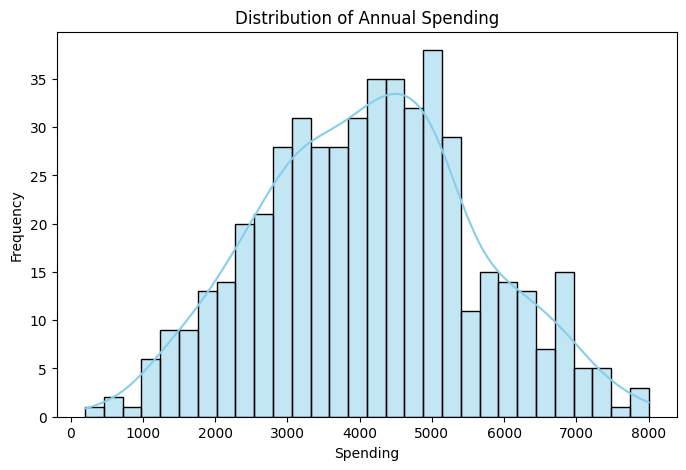

In [8]:
# Plot the distribution of annual customer spending
plt.figure(figsize=(8,5))
sns.histplot(df['spending'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Annual Spending")
plt.xlabel("Spending")
plt.ylabel("Frequency")
plt.show()



Slightly Right-skewed(Many customers spend less,Few customers spend very high amounts)

In [9]:
# Calculate skewness of the spending distribution
df['spending'].skew()


np.float64(0.06983952558391546)

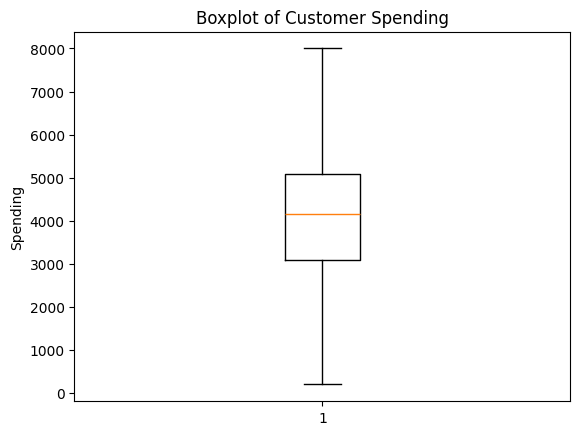

In [10]:
# Visualize spending distribution with a boxplot to detect outliers
plt.boxplot(df['spending'])
plt.title("Boxplot of Customer Spending")
plt.ylabel("Spending")
plt.show()


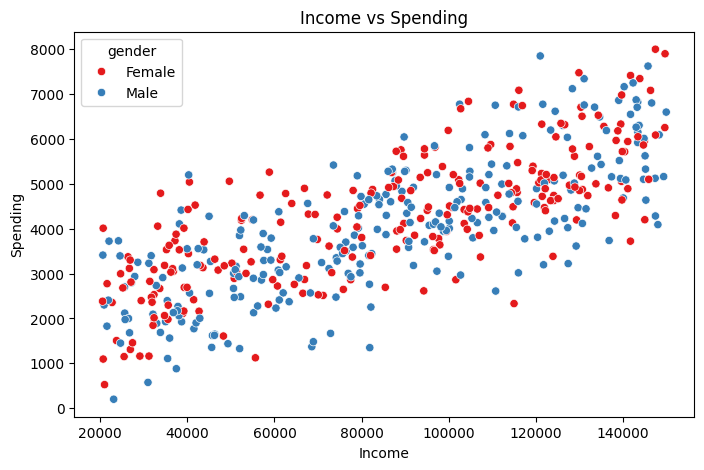

In [11]:
# Explore relationship between income and spending, colored by gender
plt.figure(figsize=(8,5))
sns.scatterplot(x='income', y='spending', data=df, hue='gender', palette='Set1')
plt.title("Income vs Spending")
plt.xlabel("Income")
plt.ylabel("Spending")
plt.show()


In [12]:
# Compute Pearson correlation
correlation = df['income'].corr(df['spending'])
print(f"Pearson Correlation between Income and Spending: {correlation:.4f}")


Pearson Correlation between Income and Spending: 0.7586


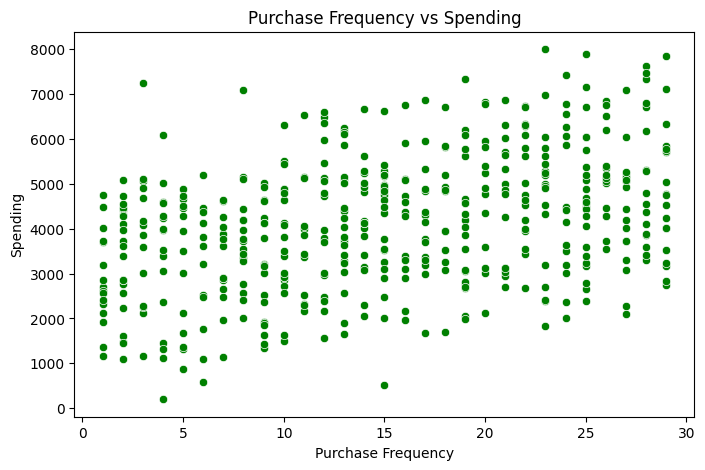

In [13]:
# Explore relationship between purchase frequency and spending
plt.figure(figsize=(8,5))
sns.scatterplot(x='purchase_frequency', y='spending', data=df, color='green')
plt.title("Purchase Frequency vs Spending")
plt.xlabel("Purchase Frequency")
plt.ylabel("Spending")
plt.show()


In [14]:
# Measure correlation between purchase frequency and spending
corr_pf = df['purchase_frequency'].corr(df['spending'])
print(f"Correlation between Purchase Frequency and Spending: {corr_pf:.4f}")


Correlation between Purchase Frequency and Spending: 0.3951


C:\Users\User\AppData\Local\Temp\ipykernel_25508\2355789893.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y='spending', data=df, palette='pastel')


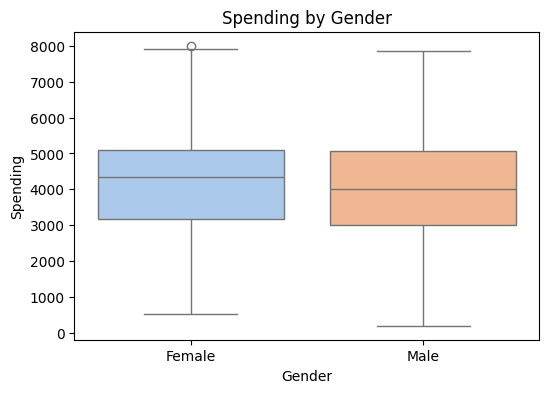

In [15]:
# Compare spending distributions across genders
plt.figure(figsize=(6,4))
sns.boxplot(x='gender', y='spending', data=df, palette='pastel')
plt.title("Spending by Gender")
plt.xlabel("Gender")
plt.ylabel("Spending")
plt.show()


In [16]:
# Summary statistics of spending grouped by gender
gender_stats = df.groupby('gender')['spending'].describe()
print(gender_stats)


        count         mean          std    min        25%       50%  \
gender                                                                
Female  240.0  4240.047167  1437.444200  525.3  3176.9325  4351.400   
Male    260.0  4028.724308  1513.037169  200.0  3004.6300  4018.915   

              75%      max  
gender                      
Female  5098.3400  8000.24  
Male    5066.7725  7850.59  


In [17]:
# Encode gender as numerical and check its correlation with spending
df['gender_encoded'] = df['gender'].map({'Male':1, 'Female':0})

corr_gender = df['gender_encoded'].corr(df['spending'])
print(f"Correlation between Gender and Spending: {corr_gender:.4f}")


Correlation between Gender and Spending: -0.0714


C:\Users\User\AppData\Local\Temp\ipykernel_25508\716571555.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='education', y='spending', data=df, palette='cool')


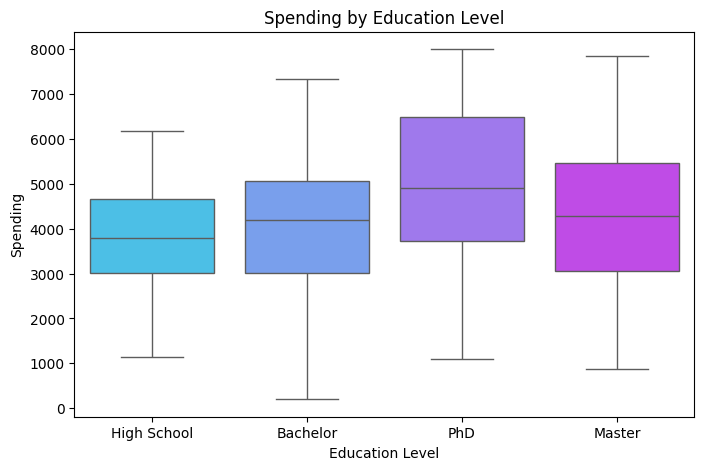

In [18]:
# Compare spending across different education levels
plt.figure(figsize=(8,5))
sns.boxplot(x='education', y='spending', data=df, palette='cool')
plt.title("Spending by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Spending")
plt.show()


In [19]:
# Summary statistics of spending grouped by education level
education_stats = df.groupby('education')['spending'].describe()
print(education_stats)


             count         mean          std      min        25%      50%  \
education                                                                   
Bachelor     211.0  4054.440521  1443.158691   200.00  3012.5100  4189.30   
High School  141.0  3777.386454  1178.389961  1150.24  3016.9800  3796.62   
Master        98.0  4361.818878  1640.702171   880.02  3046.6875  4282.52   
PhD           50.0  4990.459000  1680.745124  1095.21  3732.2275  4917.87   

                   75%      max  
education                        
Bachelor     5063.3250  7345.13  
High School  4653.9400  6181.56  
Master       5471.1700  7850.59  
PhD          6483.9025  8000.24  


In [20]:
# Perform one-way ANOVA to test if mean spending differs by education level
from scipy.stats import f_oneway

groups = [group["spending"].values
          for name, group in df.groupby("education")]

anova_result = f_oneway(*groups)
print("ANOVA F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)


ANOVA F-statistic: 9.782705243755187
p-value: 2.7958418742198195e-06


In [21]:
# Mean spending for each education level
df.groupby('education')['spending'].mean()


education
Bachelor       4054.440521
High School    3777.386454
Master         4361.818878
PhD            4990.459000
Name: spending, dtype: float64

In [22]:
# Features (X) and Target (y)
X = df.drop(columns=['spending'])
y = df['spending']


In [23]:
# Preview feature matrix X and target vector y
X.head()
y.head()


0    3183.05
1    5807.48
2    5327.88
3    5351.29
4    1123.43
Name: spending, dtype: float64

In [24]:
# List of numeric and categorical features
numeric_features = ['age', 'income', 'purchase_frequency']
categorical_features = ['gender', 'education', 'country']


In [25]:
# Build preprocessing pipeline: scale numeric features and one-hot encode categoricals
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
)


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Linear Regression pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Random Forest pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])
#Pipeline ensures preprocessing happens automatically when training/testing.

In [27]:
# Split data into training and test sets for model evaluation
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [28]:
# Train Linear Regression
lr_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [29]:
# Generate predictions on the test set using the trained Linear Regression model
y_pred_lr = lr_pipeline.predict(X_test)



In [30]:
# Evaluate Linear Regression model performance on the test set
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("R2 Score:", r2_lr)


Linear Regression Performance:
RMSE: 563.2956881536718
MAE: 447.39413198393976
R2 Score: 0.8341571693820095


In [31]:
# Compute average customer spending as a simple baseline
df['spending'].mean()


np.float64(4130.15928)

In [32]:
# Compare MAE with average spending

mean_spending = df['spending'].mean()

print("Average Spending:", mean_spending)

print("MAE as % of mean spending:",
      (mae_lr / mean_spending) * 100)


Average Spending: 4130.15928
MAE as % of mean spending: 10.832369931842914


In [33]:
# Train Random Forest model on the training data
rf_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [34]:
# Generate predictions on the test set using the trained Random Forest model
y_pred_rf = rf_pipeline.predict(X_test)


In [35]:
# Evaluate Random Forest model performance on the test set
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R2 Score:", r2_rf)


Random Forest Performance:
RMSE: 641.3131707100822
MAE: 512.8400989999999
R2 Score: 0.7850367763371846


In [36]:
# MAE as % of mean spending (Random Forest)
mean_spending = df['spending'].mean()
print("MAE as % of mean spending (RF):", (mae_rf / mean_spending) * 100)

MAE as % of mean spending (RF): 12.416956931501197


In [37]:
import warnings
warnings.filterwarnings('ignore')


In [38]:
# Cross-validate Random Forest and compute feature importances
from sklearn.model_selection import cross_val_score

cv_rf = cross_val_score(rf_pipeline, X, y, cv=5, scoring='r2')
print("Random Forest CV R²:", cv_rf.mean())
rf_model = rf_pipeline.named_steps['regressor']
importances = rf_model.feature_importances_
feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)


Random Forest CV R²: 0.8008726920016388


,Feature,Importance
1,num__income,0.671940
2,num__purchase_frequency,0.207032
0,num__age,0.039722
4,cat__education_High School,0.024315
6,cat__education_PhD,0.019997
5,cat__education_Master,0.009361
3,cat__gender_Male,0.006752
7,cat__country_Canada,0.006236
9,cat__country_UK,0.005285
8,cat__country_India,0.005006


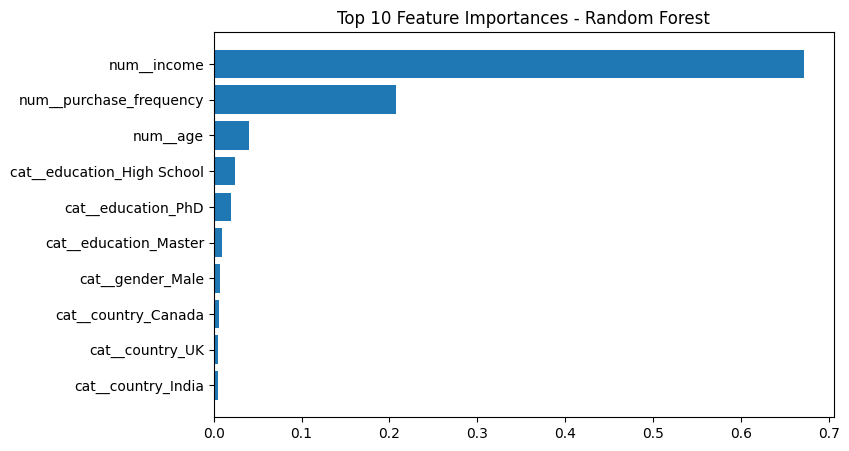

In [39]:
# Visualize top Random Forest feature importances
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(feature_importance_df['Feature'][:10],
         feature_importance_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()


In [40]:
# Tabular comparison of Linear Regression and Random Forest performance
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_rf],
    'MAE': [mae_lr, mae_rf],
    'R2 Score': [r2_lr, r2_rf]
})

comparison


,Model,RMSE,MAE,R2 Score
0,Linear Regression,563.295688,447.394132,0.834157
1,Random Forest,641.313171,512.840099,0.785037


In [41]:
import warnings
warnings.filterwarnings('ignore')


In [42]:
# Perform 5-fold cross-validation for both models and compare mean R²
from sklearn.model_selection import cross_val_score

cv_lr = cross_val_score(lr_pipeline, X, y,
                        cv=5, scoring='r2')

cv_rf = cross_val_score(rf_pipeline, X, y,
                        cv=5, scoring='r2')

print("Linear Regression CV R2:", cv_lr.mean())
print("Random Forest CV R2:", cv_rf.mean())


Linear Regression CV R2: 0.8314831520606066
Random Forest CV R2: 0.8008726920016388


In [43]:
# Extended comparison table including cross-validated R² for both models
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_rf],
    'MAE': [mae_lr, mae_rf],
    'R2 Score': [r2_lr, r2_rf],
    'CV R2': [cv_lr.mean(), cv_rf.mean()]
})
comparison


,Model,RMSE,MAE,R2 Score,CV R2
0,Linear Regression,563.295688,447.394132,0.834157,0.831483
1,Random Forest,641.313171,512.840099,0.785037,0.800873


In [44]:
# Recompute Random Forest feature importances using the fitted pipeline
rf_model = rf_pipeline.named_steps['regressor']

importances = rf_model.feature_importances_

# Get feature names after preprocessing
feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)


,Feature,Importance
1,num__income,0.671940
2,num__purchase_frequency,0.207032
0,num__age,0.039722
4,cat__education_High School,0.024315
6,cat__education_PhD,0.019997
5,cat__education_Master,0.009361
3,cat__gender_Male,0.006752
7,cat__country_Canada,0.006236
9,cat__country_UK,0.005285
8,cat__country_India,0.005006


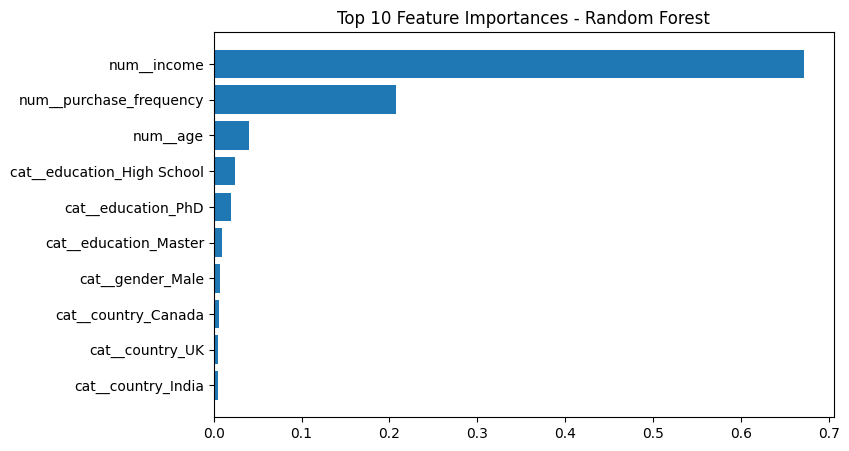

In [45]:
# Plot top 10 Random Forest feature importances
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(feature_importance_df['Feature'][:10],
         feature_importance_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()


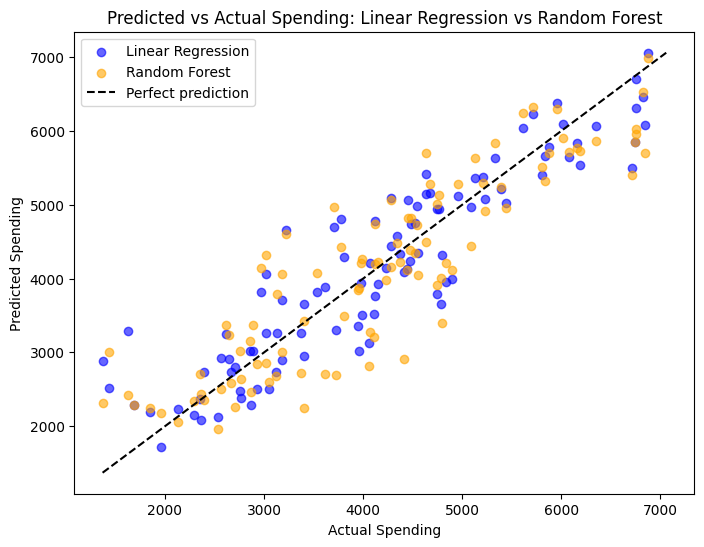

In [46]:
# Predicted vs Actual plots for Linear Regression and Random Forest
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr, alpha=0.6, label='Linear Regression', color='blue')
plt.scatter(y_test, y_pred_rf, alpha=0.6, label='Random Forest', color='orange')
max_val = max(y_test.max(), y_pred_lr.max(), y_pred_rf.max())
min_val = min(y_test.min(), y_pred_lr.min(), y_pred_rf.min())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect prediction')
plt.xlabel('Actual Spending')
plt.ylabel('Predicted Spending')
plt.title('Predicted vs Actual Spending: Linear Regression vs Random Forest')
plt.legend()
plt.show()

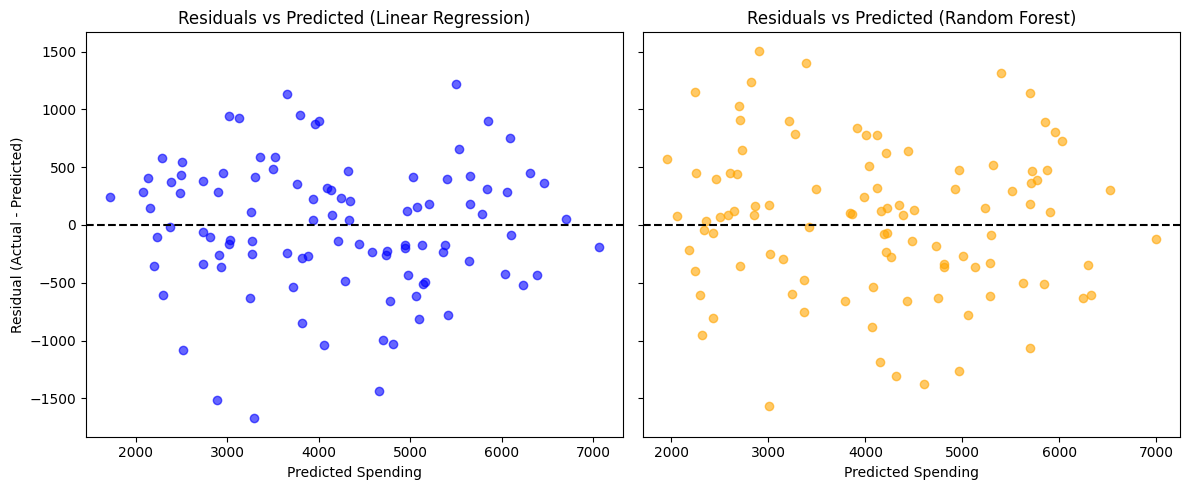

In [47]:
# Residuals vs Predicted plots for both models
residuals_lr = y_test - y_pred_lr
residuals_rf = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

axes[0].scatter(y_pred_lr, residuals_lr, alpha=0.6, color='blue')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Residuals vs Predicted (Linear Regression)')
axes[0].set_xlabel('Predicted Spending')
axes[0].set_ylabel('Residual (Actual - Predicted)')

axes[1].scatter(y_pred_rf, residuals_rf, alpha=0.6, color='orange')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Residuals vs Predicted (Random Forest)')
axes[1].set_xlabel('Predicted Spending')

plt.tight_layout()
plt.show()

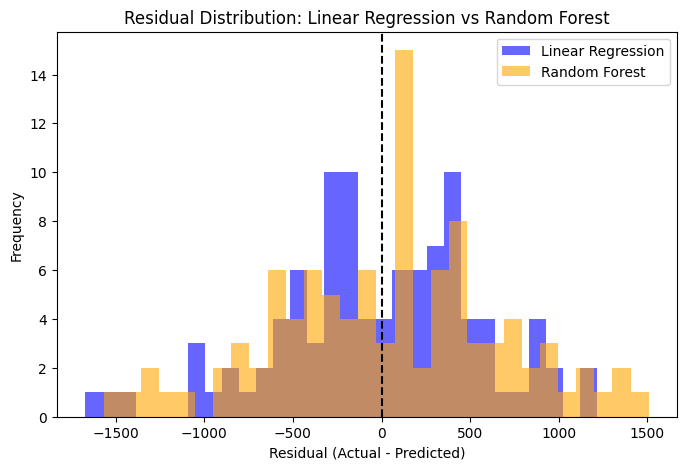

In [48]:
# Residual distribution histograms for both models
plt.figure(figsize=(8,5))
plt.hist(residuals_lr, bins=30, alpha=0.6, label='Linear Regression', color='blue')
plt.hist(residuals_rf, bins=30, alpha=0.6, label='Random Forest', color='orange')
plt.axvline(0, color='black', linestyle='--')
plt.title('Residual Distribution: Linear Regression vs Random Forest')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

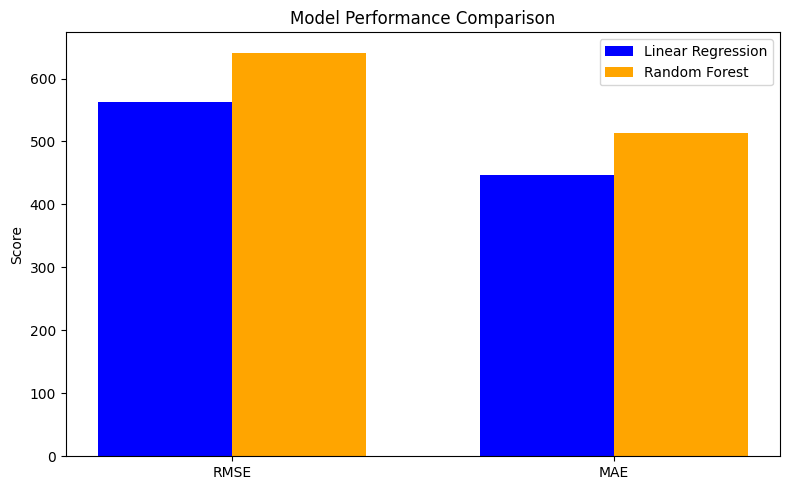

In [49]:
# Model comparison bar charts for RMSE, MAE, and R²
metrics = ['RMSE', 'MAE']
lr_scores = [rmse_lr, mae_lr]
rf_scores = [rmse_rf, mae_rf]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width/2, lr_scores, width, label='Linear Regression', color='blue')
ax.bar(x + width/2, rf_scores, width, label='Random Forest', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.legend()
plt.tight_layout()
plt.show()

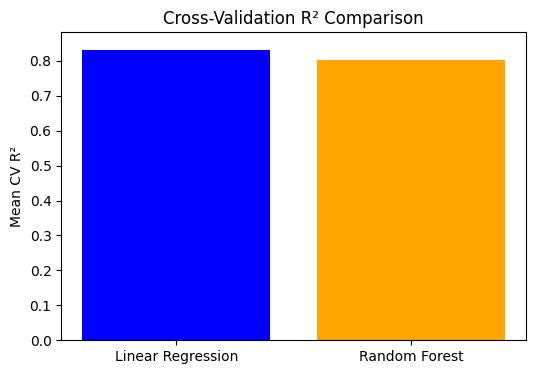

In [50]:
# Cross-validation mean R² comparison for both models
cv_scores = [cv_lr.mean(), cv_rf.mean()]
models = ['Linear Regression', 'Random Forest']

plt.figure(figsize=(6,4))
plt.bar(models, cv_scores, color=['blue', 'orange'])
plt.ylabel('Mean CV R²')
plt.title('Cross-Validation R² Comparison')
plt.ylim(0, max(cv_scores) + 0.05)
plt.show()

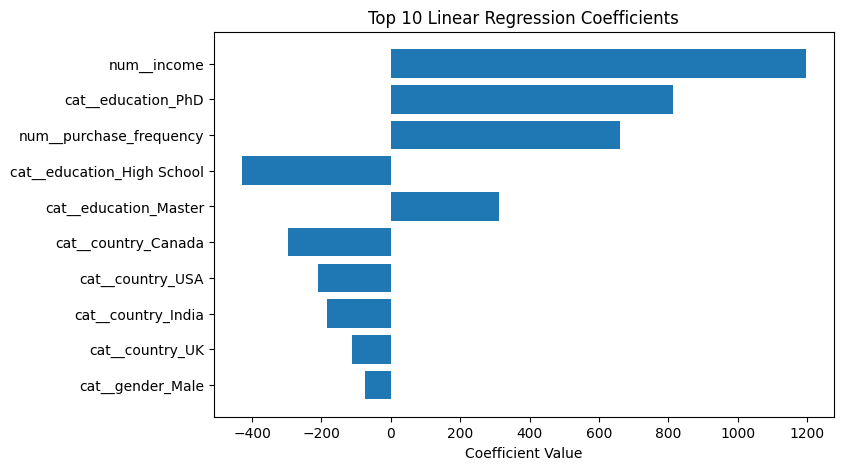

In [51]:
# Coefficient magnitude plot for Linear Regression
lin_reg = lr_pipeline.named_steps['regressor']
lr_feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()
coefficients = lin_reg.coef_
coef_df = pd.DataFrame({'Feature': lr_feature_names, 'Coefficient': coefficients})
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
top_coef_df = coef_df.sort_values('AbsCoefficient', ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.barh(top_coef_df['Feature'], top_coef_df['Coefficient'])
plt.gca().invert_yaxis()
plt.title('Top 10 Linear Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.show()

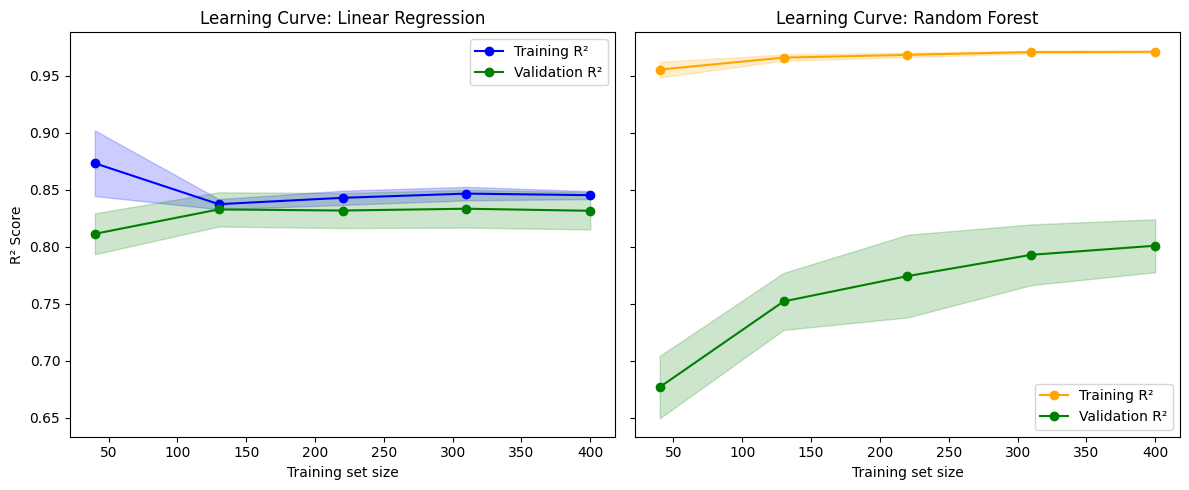

In [52]:
# Learning curves for Linear Regression and Random Forest
from sklearn.model_selection import learning_curve

train_sizes = np.linspace(0.1, 1.0, 5)

# Learning curve for Linear Regression
train_sizes_lr, train_scores_lr, val_scores_lr = learning_curve(
    lr_pipeline, X, y, cv=5, scoring='r2', train_sizes=train_sizes, n_jobs=-1
)

# Learning curve for Random Forest
train_sizes_rf, train_scores_rf, val_scores_rf = learning_curve(
    rf_pipeline, X, y, cv=5, scoring='r2', train_sizes=train_sizes, n_jobs=-1
)

train_mean_lr = train_scores_lr.mean(axis=1)
train_std_lr = train_scores_lr.std(axis=1)
val_mean_lr = val_scores_lr.mean(axis=1)
val_std_lr = val_scores_lr.std(axis=1)

train_mean_rf = train_scores_rf.mean(axis=1)
train_std_rf = train_scores_rf.std(axis=1)
val_mean_rf = val_scores_rf.mean(axis=1)
val_std_rf = val_scores_rf.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

axes[0].plot(train_sizes_lr, train_mean_lr, 'o-', color='blue', label='Training R²')
axes[0].fill_between(train_sizes_lr, train_mean_lr - train_std_lr, train_mean_lr + train_std_lr, alpha=0.2, color='blue')
axes[0].plot(train_sizes_lr, val_mean_lr, 'o-', color='green', label='Validation R²')
axes[0].fill_between(train_sizes_lr, val_mean_lr - val_std_lr, val_mean_lr + val_std_lr, alpha=0.2, color='green')
axes[0].set_title('Learning Curve: Linear Regression')
axes[0].set_xlabel('Training set size')
axes[0].set_ylabel('R² Score')
axes[0].legend()

axes[1].plot(train_sizes_rf, train_mean_rf, 'o-', color='orange', label='Training R²')
axes[1].fill_between(train_sizes_rf, train_mean_rf - train_std_rf, train_mean_rf + train_std_rf, alpha=0.2, color='orange')
axes[1].plot(train_sizes_rf, val_mean_rf, 'o-', color='green', label='Validation R²')
axes[1].fill_between(train_sizes_rf, val_mean_rf - val_std_rf, val_mean_rf + val_std_rf, alpha=0.2, color='green')
axes[1].set_title('Learning Curve: Random Forest')
axes[1].set_xlabel('Training set size')
axes[1].legend()

plt.tight_layout()
plt.show()